### LR实现简单的线性回归：

基于generated_data.csv数据，建立线性回归模型，预测x = 3.5对应的y值，评估模型的表现

# 要点
在jupyter中，运行完的单元格数据会被保存，前一步的运行完了，即使删除也会保存状态，删除后重新运行也无济于事。
所以在这里运行成功的项目复制成一个文件去运行就可能报错，因为其中的关键代码可能已经

In [3]:
# 数据加载
import pandas as pd
data = pd.read_csv('generated_data.csv')


In [10]:
# 简单查看数据
data.head()
# print(type(data),data.shape)

,x,y
0,1,7
1,2,9
2,3,11
3,4,13
4,5,15


In [11]:
# 数据data赋值
x = data.loc[:,'x']
y = data.loc[:,'y']
print(x,y)

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: x, dtype: int64 0     7
1     9
2    11
3    13
4    15
5    17
6    19
7    21
8    23
9    25
Name: y, dtype: int64


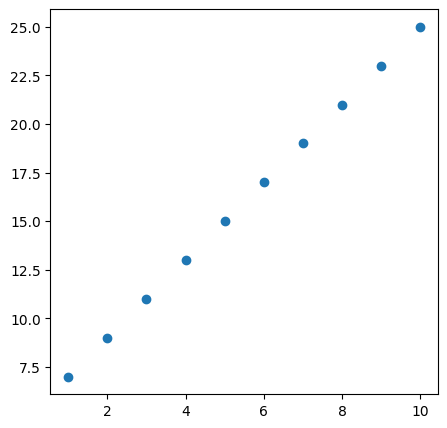

In [15]:
# 展示数据图形
from matplotlib import pyplot as plt
plt.figure(figsize=(5,5))
plt.scatter(x,y)
plt.show()

In [17]:
# 建立一个线性回归模型
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()

In [30]:
print(type(x),x.shape)
print(type(y),y.shape)
# x为一维数组，不能在线性回归模型中使用，否则会报错，所以要进行维度的转换
import numpy as np
# 需要先将数据转换为numpy.ndarray类型，才能进行reshape操作，换成二维，否则会报错
x = np.array(x)
y = np.array(y)
x = x.reshape(-1,1)
y = y.reshape(-1,1)
print(type(x),x.shape)
print(type(y),y.shape)


<class 'numpy.ndarray'> (10, 1)
<class 'numpy.ndarray'> (10, 1)
<class 'numpy.ndarray'> (10, 1)
<class 'numpy.ndarray'> (10, 1)


In [31]:
lr_model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_predict = lr_model.predict(x)
print(y_predict)

[[ 7.]
 [ 9.]
 [11.]
 [13.]
 [15.]
 [17.]
 [19.]
 [21.]
 [23.]
 [25.]]


In [33]:
print(y)

[[ 7]
 [ 9]
 [11]
 [13]
 [15]
 [17]
 [19]
 [21]
 [23]
 [25]]


In [35]:
# 预测3.5对应的Y值
y_3 = lr_model.predict([[3.5]])
print(y_3)

[[12.]]


In [36]:
# 打印模型参数a/b
a = lr_model.coef_
b = lr_model.intercept_
print(a,b)

[[2.]] [5.]


In [37]:
# 评估模型的表现
from sklearn.metrics import mean_squared_error,r2_score
MSE = mean_squared_error(y,y_predict)
R2 = r2_score(y,y_predict)
print(MSE,R2)

3.1554436208840474e-31 1.0


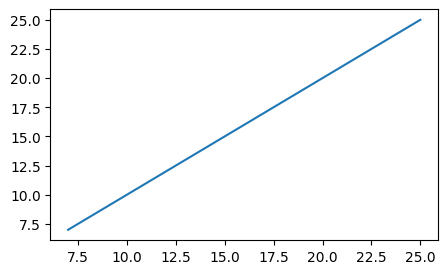

In [40]:
# 画出y与预测的y之间的图
plt.figure(figsize=(5,3))
plt.plot(y,y_predict)
plt.show()

MSE越小越好，R^2的分数越接近1越好

y' vs y 集中度越高越好

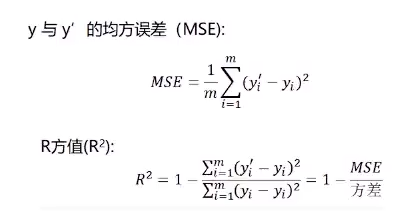